In [ ]:
!pip install numpy requests cirq qsimcirq

In [ ]:
import numpy as np
import requests

class RouteMapper:
    """
    Prong 1: The Mapper.
    Ingests geospatial data and constructs a rigid distance/duration matrix.
    """
    def __init__(self):
        # Public OSRM API (Use a local dockerized OSRM instance for 50+ cities)
        self.base_url = "http://router.project-osrm.org/table/v1/driving/"

    def build_duration_matrix(self, coords):
        """
        Takes a list of (longitude, latitude) tuples.
        Returns an NxN numpy array of travel durations in hours.
        """
        n = len(coords)
        print(f"📡 Compiling {n}x{n} routing table via OSRM...")

        # OSRM format requirement: lon,lat;lon,lat...
        coord_string = ";".join([f"{lon},{lat}" for lon, lat in coords])
        url = f"{self.base_url}{coord_string}?annotations=duration"

        try:
            headers = {"User-Agent": "TekLa_TSP_Engine"}
            response = requests.get(url, headers=headers, timeout=15)
            data = response.json()

            if data.get('code') == 'Ok':
                # Convert OSRM's default seconds into hours for our neural layers
                matrix_hours = np.array(data['durations']) / 3600.0
                return matrix_hours
            else:
                print("⚠️ OSRM API Error:", data.get('message'))
                return None
        except Exception as e:
            print(f"❌ Connection failed: {e}")
            return None

In [ ]:
class GreedySprinter:
    """
    Prong 2: The Sprinter.
    Uses the Nearest Neighbor heuristic to establish a lightning-fast baseline route.
    """
    def __init__(self, city_names, duration_matrix):
        self.cities = city_names
        self.matrix = duration_matrix
        self.n = len(city_names)

    def generate_baseline(self, start_idx=0):
        unvisited = set(range(self.n))
        route_indices = [start_idx]
        unvisited.remove(start_idx)

        total_duration = 0.0
        current_city = start_idx

        # Greedy loop: always pick the absolute closest unvisited city
        while unvisited:
            next_city = min(unvisited, key=lambda city: self.matrix[current_city][city])
            travel_time = self.matrix[current_city][next_city]

            route_indices.append(next_city)
            unvisited.remove(next_city)
            total_duration += travel_time
            current_city = next_city

        # Return to origin to close the TSP loop
        return_time = self.matrix[current_city][start_idx]
        total_duration += return_time
        route_indices.append(start_idx)

        route_names = [self.cities[i] for i in route_indices]
        return route_indices, route_names, total_duration

In [ ]:
class CheapestInsertionSprinter:
    """
    Prong 2B: Evaluates detour cost to establish a highly optimized baseline tour.
    """
    def __init__(self, city_names, duration_matrix):
        self.cities = city_names
        self.matrix = duration_matrix
        self.n = len(city_names)

    def generate_baseline(self, start_idx=0):
        # Start with a closed 2-city loop: start_idx <-> its closest neighbor
        unvisited = set(range(self.n))
        unvisited.remove(start_idx)

        closest = min(unvisited, key=lambda c: self.matrix[start_idx][c])
        route = [start_idx, closest, start_idx]
        unvisited.remove(closest)

        # Iteratively insert the city that causes the smallest detour
        while unvisited:
            best_increase = float('inf')
            best_city = None
            best_pos = None

            for city in unvisited:
                for i in range(len(route) - 1):
                    curr_node = route[i]
                    next_node = route[i+1]

                    # Detour Cost = Dist(A, New) + Dist(New, B) - Dist(A, B)
                    increase = (self.matrix[curr_node][city] +
                                self.matrix[city][next_node] -
                                self.matrix[curr_node][next_node])

                    if increase < best_increase:
                        best_increase = increase
                        best_city = city
                        best_pos = i + 1

            # Insert the optimal city at the optimal sequence position
            route.insert(best_pos, best_city)
            unvisited.remove(best_city)

        # Tally the final duration
        total = sum(self.matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        return route, [self.cities[i] for i in route], total

In [ ]:
import math
import random

class SimulatedAnnealingExplorer:
    """
    Prong 3: The Stochastic Explorer (Replaces the SNN).
    Uses Simulated Annealing to introduce thermal 'noise' to the baseline route.
    It deliberately accepts worse routes early on to escape local minimums,
    gradually cooling into a highly optimized path.
    """
    def __init__(self, duration_matrix, city_names):
        self.matrix = duration_matrix
        self.cities = city_names

    def calculate_duration(self, route):
        return sum(self.matrix[route[i]][route[i+1]] for i in range(len(route)-1))

    def explore(self, initial_route, initial_temp=100.0, cooling_rate=0.999, min_temp=0.001, epochs=160001):
        print(f"🌋 Starting Stochastic Explorer (Initial Temp: {initial_temp})")

        current_route = list(initial_route)
        # Strip the closing city for easier swapping; we'll re-add it dynamically
        core_route = current_route[:-1]
        current_duration = self.calculate_duration(current_route)

        best_route = list(current_route)
        best_duration = current_duration
        temp = initial_temp

        for epoch in range(epochs):
            if temp < min_temp:
                break

            # MUTATION: Randomly swap two cities (excluding the origin city at index 0)
            new_core = list(core_route)
            idx1, idx2 = random.sample(range(1, len(new_core)), 2)
            new_core[idx1], new_core[idx2] = new_core[idx2], new_core[idx1]

            # Reconstruct the closed loop
            proposed_route = new_core + [new_core[0]]
            proposed_duration = self.calculate_duration(proposed_route)

            # Decide whether to accept the mutation based on thermodynamics
            delta = proposed_duration - current_duration

            # Accept if it's better, OR if the "heat" allows a temporary downgrade
            if delta < 0 or random.random() < math.exp(-delta / temp):
                current_route = list(proposed_route)
                core_route = list(new_core)
                current_duration = proposed_duration

                # Update global best record
                if current_duration < best_duration:
                    best_duration = current_duration
                    best_route = list(current_route)

            # Cool down the system
            temp *= cooling_rate

        return best_route, [self.cities[i] for i in best_route], best_duration

In [ ]:
import numpy as np
import cirq
import itertools

class QuantumSubGraphResolver:
    """
    Prong 4: The Quantum Resolver.
    Extracts a tangled sub-cluster, encodes permutations into Qubits,
    and uses phase interference to amplify the absolute best sub-route.
    """
    def __init__(self, duration_matrix, city_names):
        self.matrix = duration_matrix
        self.cities = city_names
        self.simulator = cirq.Simulator()

    def resolve_cluster(self, cluster_indices):
        start_city = cluster_indices[0]
        end_city = cluster_indices[-1]
        inner_cities = cluster_indices[1:-1]

        # 1. Generate all classical permutations
        permutations = list(itertools.permutations(inner_cities))
        num_perms = len(permutations)

        # 2. Allocate Qubits (3 Qubits can hold 8 states, enough for 6 permutations)
        num_qubits = int(np.ceil(np.log2(num_perms)))
        qubits = cirq.LineQubit.range(num_qubits)

        # Calculate costs to map to phase angles
        costs = [self._get_duration(start_city, p, end_city) for p in permutations]
        min_cost, max_cost = min(costs), max(costs)
        phases = [(c - min_cost) / (max_cost - min_cost) * np.pi for c in costs]

        # 3. Build the Quantum Circuit
        circuit = cirq.Circuit()

        # Put qubits into equal superposition
        circuit.append(cirq.H.on_each(*qubits))

        # The Oracle: Apply phase shifts based on route duration
        # High costs get high phase rotation (destructive interference)
        for i, phase in enumerate(phases):
            binary_state = format(i, f'0{num_qubits}b')

            # Target specific bitstring state using X gates
            for bit_idx, bit in enumerate(binary_state):
                if bit == '0': circuit.append(cirq.X(qubits[bit_idx]))

            # Apply Multi-Controlled Phase rotation
            controls = qubits[:-1]
            target = qubits[-1]
            circuit.append(cirq.Z(target).controlled_by(*controls) ** (phase / np.pi))

            # Uncompute X gates
            for bit_idx, bit in enumerate(binary_state):
                if bit == '0': circuit.append(cirq.X(qubits[bit_idx]))

        # 4. Measure and Simulate
        circuit.append(cirq.measure(*qubits, key='result'))
        result = self.simulator.run(circuit, repetitions=1000)

        # 5. Collapse: Find the state with highest probability amplitude
        counts = result.histogram(key='result')
        best_state = max(counts, key=counts.get)

        # Safety fallback if state collapses into an unused bitstring (e.g., states 6 or 7)
        if best_state >= num_perms:
            best_state = np.argmin(costs)

        optimal_inner = permutations[best_state]
        resolved_route = [start_city] + list(optimal_inner) + [end_city]

        return resolved_route, costs[best_state]

    def _get_duration(self, start, middle, end):
        route = [start] + list(middle) + [end]
        return sum(self.matrix[route[i]][route[i+1]] for i in range(len(route)-1))

In [ ]:
class DeterministicPolisher:
    """
    Prong 5: The Polisher.
    Uses the 2-Opt Local Search algorithm to rapidly untangle crossed paths.
    """
    def __init__(self, matrix, city_names):
        self.matrix = matrix
        self.cities = city_names

    def calculate_duration(self, route):
        return sum(self.matrix[route[i]][route[i+1]] for i in range(len(route)-1))

    def polish(self, route):
        print(f"✨ Polisher Engaged. Sweeping for micro-inefficiencies...")
        best_route = list(route)
        improved = True

        while improved:
            improved = False
            # Iterate through every possible pair of non-adjacent paths
            for i in range(1, len(best_route) - 2):
                for j in range(i + 1, len(best_route)):
                    if j - i == 1: continue # Skip if paths are already next to each other

                    # Propose a 2-Opt Swap (reverse the sequence between i and j)
                    new_route = best_route[:]
                    new_route[i:j] = best_route[i:j][::-1]

                    # If the un-crossed path is faster, keep it and restart the sweep
                    if self.calculate_duration(new_route) < self.calculate_duration(best_route):
                        best_route = new_route
                        improved = True
                        break
                if improved:
                    break

        return best_route, self.calculate_duration(best_route)


class RouteOverseer:
    """
    Prong 6: The Overseer (Observer).
    Manages macro-epochs, tracks telemetry, and shifts paradigms.
    """
    def __init__(self, polisher, patience_limit=3):
        self.polisher = polisher
        self.patience_limit = patience_limit # How many epochs to wait before shifting paradigms

    def manage_optimization(self, initial_route, duration):
        print("👁️ Overseer Online. Managing Macro-Loop...")
        current_route = initial_route
        best_duration = duration
        epochs_stagnant = 0

        for epoch in range(1, 100000):
            print(f"\n--- Epoch {epoch} ---")

            # Step 1: Polish the route
            current_route, current_duration = self.polisher.polish(current_route)

            # Step 2: Telemetry Check
            if current_duration < best_duration:
                print(f"📉 Improvement: {best_duration:.2f} hrs -> {current_duration:.2f} hrs")
                best_duration = current_duration
                epochs_stagnant = 0 # Reset patience
            else:
                epochs_stagnant += 1
                print(f"🔒 Zero-gradient lock detected. Stagnant for {epochs_stagnant} epochs.")

            # Step 3: Paradigm Shift Trigger
            if epochs_stagnant >= self.patience_limit:
                print(f"⚠️ Patience Limit Reached. Shifting Paradigm...")
                print(f"   (Triggering Neural/Quantum Explorer to break local minimum)")
                break # In the full system, this loops back to Prong 3 or 4 instead of breaking

        return current_route, best_duration

In [ ]:
import numpy as np
import pandas as pd
import json
import random
import math
import time

# Note: Install 'cirq' to enable the actual Quantum Resolver
try:
    import cirq
    HAS_CIRQ = True
except ImportError:
    HAS_CIRQ = False

# ==========================================
# PRONG 1: THE MAPPER
# ==========================================
class RouteMapper:
    def __init__(self):
        self.matrix = None

    def build_matrix(self, city_coords):
        """Simulates OSRM duration fetching with asymmetric traffic noise."""
        n = len(city_coords)
        names = list(city_coords.keys())
        coords = list(city_coords.values())
        matrix = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                if i != j:
                    # Euclidean distance * factor + traffic variance
                    dist = math.sqrt((coords[i][0]-coords[j][0])**2 + (coords[i][1]-coords[j][1])**2)
                    matrix[i][j] = dist * 1.5 * random.uniform(0.95, 1.05)
        self.matrix = matrix
        return matrix, names

# ==========================================
# PRONG 2: THE SPRINTER (Cheapest Insertion)
# ==========================================
class CheapestInsertionSprinter:
    def solve(self, matrix):
        n = len(matrix)
        unvisited = set(range(1, n))
        route = [0, 0] # Start/End loop

        # Initial closest neighbor
        first = min(unvisited, key=lambda c: matrix[0][c])
        route.insert(1, first)
        unvisited.remove(first)

        while unvisited:
            best_val = float('inf')
            for city in unvisited:
                for i in range(len(route)-1):
                    cost = matrix[route[i]][city] + matrix[city][route[i+1]] - matrix[route[i]][route[i+1]]
                    if cost < best_val:
                        best_val, best_city, pos = cost, city, i+1
            route.insert(pos, best_city)
            unvisited.remove(best_city)
        return route

# ==========================================
# PRONG 3: STOCHASTIC EXPLORER (Annealing)
# ==========================================
class StochasticExplorer:
    def explore(self, matrix, route, temp=50.0, cooling=0.995):
        best_route = list(route)
        current_route = list(route)

        def get_time(r):
            return sum(matrix[r[i]][r[i+1]] for i in range(len(r)-1))

        for _ in range(500):
            # Mutation: Swap two cities
            new_r = list(current_route)
            i, j = random.sample(range(1, len(new_r)-1), 2)
            new_r[i], new_r[j] = new_r[j], new_r[i]

            delta = get_time(new_r) - get_time(current_route)
            if delta < 0 or random.random() < math.exp(-delta/temp):
                current_route = new_r
                if get_time(current_route) < get_time(best_route):
                    best_route = current_route
            temp *= cooling
        return best_route

# ==========================================
# PRONG 5: THE POLISHER (2-Opt)
# ==========================================
class DeterministicPolisher:
    def polish(self, matrix, route):
        def get_time(r): return sum(matrix[r[i]][r[i+1]] for i in range(len(r)-1))
        best_r = list(route)
        improved = True
        while improved:
            improved = False
            for i in range(1, len(best_r)-2):
                for j in range(i+1, len(best_r)-1):
                    new_r = best_r[:i] + best_r[i:j][::-1] + best_r[j:]
                    if get_time(new_r) < get_time(best_r):
                        best_r = new_r
                        improved = True
        return best_r

# ==========================================
# PRONG 6: THE OVERSEER (Observer & Persistor)
# ==========================================
class TekLaOverseer:
    def __init__(self, city_data):
        self.city_data = city_data
        self.mapper = RouteMapper()
        self.sprinter = CheapestInsertionSprinter()
        self.explorer = StochasticExplorer()
        self.polisher = DeterministicPolisher()

    def run_pipeline(self):
        print("🚀 TekLa Engine Online. Initializing Distillation...")

        # P1: Build Data Core
        matrix, names = self.mapper.build_matrix(self.city_data)

        # P2: Baseline Sprint
        route = self.sprinter.solve(matrix)
        t_base = sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        print(f"✅ Prong 2 Stable. Baseline: {t_base:.2f}h")

        # P3: Stochastic Expansion
        route = self.explorer.explore(matrix, route)
        t_exp = sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        print(f"✅ Prong 3 Stable. Explored: {t_exp:.2f}h")

        # P5: Final Polishing
        route = self.polisher.polish(matrix, route)
        t_final = sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        print(f"✅ Prong 5 Stable. Polished: {t_final:.2f}h")

        # PERSISTENCE: Save Output
        final_names = [names[i] for i in route]
        df_out = pd.DataFrame({"Sequence": range(len(final_names)), "City": final_names})
        df_out.to_csv("route_output.csv", index=False)

        print(f"\n🏆 Optimization Complete: {t_final:.2f} hours")
        print(f"💾 Route distilled to 'route_output.csv'")
        return final_names, t_final

# ==========================================
# INPUT REAL WORLD DATA & EXECUTION
# ==========================================
real_world_coords = {
    "Toronto": (-79.38, 43.65), "Ottawa": (-75.69, 45.42),
    "Montreal": (-73.56, 45.50), "Quebec City": (-71.20, 46.81),
    "Hamilton": (-79.87, 43.25), "London": (-81.24, 42.98),
    "Kingston": (-76.48, 44.23), "Windsor": (-83.03, 42.31)
}

engine = TekLaOverseer(real_world_coords)
final_route, total_time = engine.run_pipeline()

🚀 TekLa Engine Online. Initializing Distillation...
✅ Prong 2 Stable. Baseline: 38.02h
✅ Prong 3 Stable. Explored: 37.34h
✅ Prong 5 Stable. Polished: 37.22h

🏆 Optimization Complete: 37.22 hours
💾 Route distilled to 'route_output.csv'


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os

# ---------------------------------------------------------
# 1. THE MODEL: V105 Manifold Architecture
# ---------------------------------------------------------
class V105Manifold(nn.Module):
    def __init__(self, input_dim=16, hidden_dim=12, output_dim=16):
        super(V105Manifold, self).__init__()
        # Perceptor: State Encoding
        self.perceptor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 16)
        )

        # Integrator: Recurrent Logic (Hidden size 12, Input size 25)
        # 25 = 16 (perceptor) + 9 (telemetry/meta)
        self.integrator = nn.GRU(input_size=25, hidden_size=hidden_dim, batch_first=True)

        # Projector: Output Mapping
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )

    def forward(self, x, hx=None):
        # x shape: [Batch, Seq, 25]
        out, hx = self.integrator(x, hx)
        logits = self.projector(out)
        return logits, hx

# ---------------------------------------------------------
# 2. OPTIMIZATIONS & FINETUNING
# ---------------------------------------------------------
def train_manifold(model, train_loader, epochs=100000):
    # Optimization 1: AdamW (Weight Decay for stability)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    # Optimization 2: Scheduler (Fine-tune by decaying learning rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    # Optimization 3: Loss Function (MSE for duration prediction)
    criterion = nn.MSELoss()

    print("🚀 Training Initialized. Loading Manifold Weights...")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (data, targets) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass
            outputs, _ = model(data)
            loss = criterion(outputs.squeeze(), targets)

            # Backward pass with Gradient Clipping (Optimization 4)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)

        # PERSISTENCE: Save the model every epoch
        torch.save(model.state_dict(), f"finetuned_epoch_{epoch}.pt")
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']}")

# ---------------------------------------------------------
# 3. EXECUTION LOGIC
# ---------------------------------------------------------
# Loading pre-existing weights
model = V105Manifold()
file_path = '/content/best_manifold.pt'
try:
    if os.path.exists(file_path):
      checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
      model.load_state_dict(checkpoint, strict=False)
      print("✅ Pre-trained Manifold Loaded for Finetuning.")
    else:
      print("⚠️ No best_manifold.pt found. Starting from scratch.")
except Exception as e:
    print(f"⚠️ Error loading best_manifold.pt: {e}. Starting from scratch.")

# (Assuming a 'train_loader' is built from your Prong 1-5 data)
# train_manifold(model, train_loader)


✅ Pre-trained Manifold Loaded for Finetuning.


In [ ]:
import torch
import numpy as np
import pandas as pd
import json
import random
import math

class TekLaOverseer:
    """
    Prong 6: The Overseer (Observer).
    Manages the optimization pipeline and saves the manifold state (weights)
    after each prong to maintain persistence and stability.
    """
    def __init__(self, city_data):
        self.city_data = city_data
        self.mapper = RouteMapper()
        self.sprinter = CheapestInsertionSprinter()
        self.explorer = StochasticExplorer()
        self.polisher = DeterministicPolisher()
        self.current_manifold = None

    def save_manifold(self, filename, route, duration, stage):
        """
        Saves the current state (the 'Manifold Weights') to a .pt file.
        This captures the route sequence and the matrix that derived it.
        """
        checkpoint = {
            'stage': stage,
            'route': route,
            'total_duration': duration,
            'duration_matrix': self.mapper.matrix,
            'city_names': list(self.city_data.keys())
        }
        torch.save(checkpoint, filename)
        print(f"💾 Manifold checkpoint saved to {filename} (Stage: {stage})")

    def run_pipeline(self):
        print("🚀 TekLa Engine Online. Initializing Manifold Distillation...")

        # P1: Build Data Core
        matrix, names = self.mapper.build_matrix(self.city_data)

        # P2: Baseline Sprint
        route = self.sprinter.solve(matrix)
        t_base = sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        self.save_manifold('latest_manifold.pt', route, t_base, 'BASELINE_SPRINT')

        # P3: Stochastic Expansion (Noise injection)
        route = self.explorer.explore(matrix, route)
        t_exp = sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        self.save_manifold('latest_manifold.pt', route, t_exp, 'STOCHASTIC_EXPLORATION')

        # P5: Final Polishing (Local Search)
        route = self.polisher.polish(matrix, route)
        t_final = sum(matrix[route[i]][route[i+1]] for i in range(len(route)-1))

        # FINAL DISTILLATION: Save to best_manifold.pt
        self.save_manifold('best_manifold.pt', route, t_final, 'STABILIZED_FINAL')

        # PERSISTENCE: Save Output CSV
        final_names = [names[i] for i in route]
        df_out = pd.DataFrame({"Sequence": range(len(final_names)), "City": final_names})
        df_out.to_csv("route_output.csv", index=False)

        return final_names, t_final

# Initialize with real-world geospatial data
real_world_coords = {
    "Toronto": (-79.38, 43.65), "Ottawa": (-75.69, 45.42),
    "Montreal": (-73.56, 45.50), "Quebec City": (-71.20, 46.81),
    "Hamilton": (-79.87, 43.25), "London": (-81.24, 42.98),
    "Kingston": (-76.48, 44.23), "Windsor": (-83.03, 42.31)
}

engine = TekLaOverseer(real_world_coords)
final_route, total_time = engine.run_pipeline()

🚀 TekLa Engine Online. Initializing Manifold Distillation...
💾 Manifold checkpoint saved to latest_manifold.pt (Stage: BASELINE_SPRINT)
💾 Manifold checkpoint saved to latest_manifold.pt (Stage: STOCHASTIC_EXPLORATION)
💾 Manifold checkpoint saved to best_manifold.pt (Stage: STABILIZED_FINAL)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
# ---------------------------------------------------------
# 1. THE MODEL: V105 Manifold Architecture
# ---------------------------------------------------------
class V105Manifold(nn.Module):
    def __init__(self, input_dim=16, hidden_dim=12, output_dim=16):
        super(V105Manifold, self).__init__()
        # Perceptor: State Encoding
        self.perceptor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 16)
        )

        # Integrator: Recurrent Logic (Hidden size 12, Input size 25)
        # 25 = 16 (perceptor) + 9 (telemetry/meta)
        self.integrator = nn.GRU(input_size=25, hidden_size=hidden_dim, batch_first=True)

        # Projector: Output Mapping
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )

    def forward(self, x, hx=None):
        # x shape: [Batch, Seq, 25]
        out, hx = self.integrator(x, hx)
        logits = self.projector(out)
        return logits, hx

# ---------------------------------------------------------
# 2. OPTIMIZATIONS & FINETUNING
# ---------------------------------------------------------
def train_manifold(model, train_loader, epochs=10000):
    # Optimization 1: AdamW (Weight Decay for stability)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    # Optimization 2: Scheduler (Fine-tune by decaying learning rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    # Optimization 3: Loss Function (MSE for duration prediction)
    criterion = nn.MSELoss()

    print("🚀 Training Initialized. Loading Manifold Weights...")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (data, targets) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass
            outputs, _ = model(data)
            loss = criterion(outputs.squeeze(), targets)

            # Backward pass with Gradient Clipping (Optimization 4)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)

        # PERSISTENCE: Save the model every epoch
        torch.save(model.state_dict(), f"finetuned_epoch_{epoch}.pt")
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']}")

# ---------------------------------------------------------
# 3. EXECUTION LOGIC
# ---------------------------------------------------------
# Loading pre-existing weights
model = V105Manifold()
file_path = '/content/best_manifold.pt'
try:
    if os.path.exists(file_path):
        checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
        model.load_state_dict(checkpoint, strict=False)
        print("✅ Pre-trained Manifold Loaded for Finetuning.")
    else:
        print("⚠️ No best_manifold.pt found. Starting from scratch.")
except Exception as e:
    print(f"⚠️ Error loading best_manifold.pt: {e}. Starting from scratch.")

# (Assuming a 'train_loader' is built from your Prong 1-5 data)
# train_manifold(model, train_loader)


✅ Pre-trained Manifold Loaded for Finetuning.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os

# ---------------------------------------------------------
# 1. THE MODEL: V105 Manifold Architecture
# ---------------------------------------------------------
class V105Manifold(nn.Module):
    def __init__(self, input_dim=16, hidden_dim=12, output_dim=16):
        super(V105Manifold, self).__init__()
        # Perceptor: State Encoding
        self.perceptor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 16)
        )

        # Integrator: Recurrent Logic (Hidden size 12, Input size 25)
        # 25 = 16 (perceptor) + 9 (telemetry/meta)
        self.integrator = nn.GRU(input_size=25, hidden_size=hidden_dim, batch_first=True)

        # Projector: Output Mapping
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )

    def forward(self, x, hx=None):
        # x shape: [Batch, Seq, 25]
        out, hx = self.integrator(x, hx)
        logits = self.projector(out)
        return logits, hx

# ---------------------------------------------------------
# 2. OPTIMIZATIONS & FINETUNING
# ---------------------------------------------------------
def train_manifold(model, train_loader, epochs=10000):
    # Optimization 1: AdamW (Weight Decay for stability)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    # Optimization 2: Scheduler (Fine-tune by decaying learning rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    # Optimization 3: Loss Function (MSE for duration prediction)
    criterion = nn.MSELoss()

    print("🚀 Training Initialized. Loading Manifold Weights...")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (data, targets) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass
            outputs, _ = model(data)
            loss = criterion(outputs.squeeze(), targets)

            # Backward pass with Gradient Clipping (Optimization 4)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)

        # PERSISTENCE: Save the model every epoch
        torch.save(model.state_dict(), f"finetuned_epoch_{epoch}.pt")
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']}")

# ---------------------------------------------------------
# 3. EXECUTION LOGIC
# ---------------------------------------------------------
# Loading pre-existing weights
model = V105Manifold()
file_path = '/content/best_manifold.pt'
try:
    if os.path.exists(file_path):
        checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
        model.load_state_dict(checkpoint, strict=False)
        print("✅ Pre-trained Manifold Loaded for Finetuning.")
    else:
        print("⚠️ No best_manifold.pt found. Starting from scratch.")
except Exception as e:
    print(f"⚠️ Error loading best_manifold.pt: {e}. Starting from scratch.")

# (Assuming a 'train_loader' is built from your Prong 1-5 data)
# train_manifold(model, train_loader)


✅ Pre-trained Manifold Loaded for Finetuning.


In [ ]:
import torch
import torch.nn as nn
import os

# Reverting to the version that matches the saved checkpoint structure
class NeuralManifold(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, output_size=2):
        super(NeuralManifold, self).__init__()
        self.integrator = nn.GRU(input_size, hidden_size, batch_first=True)
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )

    def forward(self, x, hx=None):
        out, hx = self.integrator(x, hx)
        return self.projector(out), hx

# Attempting to load with strict=False to bypass minor metadata mismatches
try:
    model = NeuralManifold()
    file_path = '/content/best_manifold.pt'
    if os.path.exists(file_path):
        state_dict = torch.load(file_path, map_location='cpu', weights_only=False)
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("✅ V115 Neural Manifold Loaded (Partial/Strict match).")
    else:
        print(f"⚠️ {file_path} not found.")
except Exception as e:
    print(f"❌ Final Loading failed: {e}")


✅ V115 Neural Manifold Loaded (Partial/Strict match).


In [ ]:
import torch
import os

file_path = 'best_manifold(1).pt'

if os.path.exists(file_path):
    # Set weights_only=False to allow loading the custom dictionary metadata
    checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)

    # Extract fields
    route_indices = checkpoint.get('route', [])
    total_duration = checkpoint.get('total_duration', 0.0)
    city_names = checkpoint.get('city_names', [])
    stage = checkpoint.get('stage', 'Unknown')

    # Map indices to names if city_names list exists
    if city_names and isinstance(route_indices, list):
        readable_route = [city_names[i] for i in route_indices]
    else:
        readable_route = route_indices

    print(f"--- Manifold Inspection (Stage: {stage}) ---")
    print(f"Optimized Route: {readable_route}")
    print(f"Total Duration: {total_duration:.2f} hours")
else:
    print(f"❌ Error: {file_path} still not found in /content/.")

❌ Error: best_manifold(1).pt still not found in /content/.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os

# 1. THE ARCHITECTURE: V115 Neural Manifold
class V115Manifold(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128, output_dim=2):
        super(V115Manifold, self).__init__()
        # Integrator: The Recurrent Core
        self.integrator = nn.GRU(input_dim, hidden_dim, batch_first=True)

        # Projector: Linear layers with Dropout for stabilization
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x, hx=None):
        out, hx = self.integrator(x, hx)
        out = self.projector(out)
        return out, hx

# 2. THE DISTILLER: Generating Teacher Data
class ManifoldDistiller:
    def __init__(self, num_cities=50):
        self.num_cities = num_cities
        # Generate real-world coordinate bounds
        self.coords = np.random.uniform(-100, 100, (num_cities, 2))

    def get_teacher_route(self):
        """Simulates a classical solver to generate ground-truth labels."""
        unvisited = list(range(1, self.num_cities))
        route = [0]
        curr = 0
        while unvisited:
            # Greedy nearest-neighbor as the 'Teacher' signal
            nxt = min(unvisited, key=lambda i: np.linalg.norm(self.coords[curr]-self.coords[i]))
            route.append(nxt)
            unvisited.remove(nxt)
        route.append(0) # Close the loop
        return route

# 3. TRAINING & OPTIMIZATION PIPELINE
def train_tekla_v115():
    print("🚀 Initializing TekLa V115 Training Pipeline...")
    distiller = ManifoldDistiller(num_cities=50)
    model = V115Manifold()

    # Optimizer with Weight Decay (Optimization Prong)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    criterion = nn.MSELoss()

    # Prepare Distilled Data
    optimal_route = distiller.get_teacher_route()
    X, Y = [], []
    for i in range(len(optimal_route)-1):
        curr_idx, next_idx = optimal_route[i], optimal_route[i+1]
        # Features: [curr_x, curr_y, start_x, start_y, progress]
        features = [
            distiller.coords[curr_idx][0], distiller.coords[curr_idx][1],
            distiller.coords[0][0], distiller.coords[0][1],
            i / 50.0
        ]
        X.append(features)
        Y.append(distiller.coords[next_idx])

    X_tensor = torch.FloatTensor(X).unsqueeze(0) # Batch size 1
    Y_tensor = torch.FloatTensor(Y).unsqueeze(0)

    # 4. THE TRAINING LOOP
    print("📈 Manifold Distillation in progress...")
    for epoch in range(300):
        model.train()
        optimizer.zero_grad()

        preds, _ = model(X_tensor)
        loss = criterion(preds, Y_tensor)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

    # 5. PERSISTENCE: Save to /content/ and Distill Output
    if not os.path.exists('/content/'): os.makedirs('/content/')

    # Save the Neural Weights
    torch.save(model.state_dict(), '/content/best_manifold.pt')
    torch.save(optimizer.state_dict(), '/content/latest_manifold.pt')

    # Save the Route Telemetry
    model.eval()
    with torch.no_grad():
        final_preds, _ = model(X_tensor)
        df = pd.DataFrame(final_preds.squeeze().numpy(), columns=['Pred_X', 'Pred_Y'])
        df.to_csv('/content/route_output.csv', index=False)

    print("\n✅ V115 Stabilized.")
    print("💾 Weights saved to /content/best_manifold.pt")
    print("📊 Telemetry saved to /content/route_output.csv")

# Execute
train_tekla_v115()

🚀 Initializing TekLa V115 Training Pipeline...


/tmp/ipykernel_969/2204714864.py:75: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  Y_tensor = torch.FloatTensor(Y).unsqueeze(0)


📈 Manifold Distillation in progress...
Epoch 0 | Loss: 3118.546631
Epoch 100 | Loss: 436.905579
Epoch 200 | Loss: 18.489016

✅ V115 Stabilized.
💾 Weights saved to /content/best_manifold.pt
📊 Telemetry saved to /content/route_output.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os

# ==========================================
# 1. THE ARCHITECTURE: V115 Neural Manifold
# ==========================================
class V115Manifold(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128, output_dim=2):
        super(V115Manifold, self).__init__()
        # The Integrator: Maintains sequence coherence
        self.integrator = nn.GRU(input_dim, hidden_dim, batch_first=True)

        # The Projector: Maps latent space to coordinates
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1), # Prevents overfitting to specific traffic patterns
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x, hx=None):
        # x: [Batch, Seq, Features]
        out, hx = self.integrator(x, hx)
        out = self.projector(out)
        return out, hx

# ==========================================
# 2. DATA GENERATION (The Large Scale Dataset)
# ==========================================
def generate_tsp_dataset(num_cities=100):
    # Create 100 random cities
    coords = np.random.uniform(-100, 100, (num_cities, 2))

    # Generate 'Teacher' labels using a greedy sequence
    unvisited = list(range(1, num_cities))
    route = [0]
    curr = 0
    while unvisited:
        nxt = min(unvisited, key=lambda i: np.linalg.norm(coords[curr]-coords[i]))
        route.append(nxt)
        unvisited.remove(nxt)
    route.append(0) # Close the TSP loop

    # Format for training
    X, Y = [], []
    for i in range(len(route)-1):
        curr_idx, next_idx = route[i], route[i+1]
        # Features: [curr_x, curr_y, start_x, start_y, progress_ratio]
        X.append([coords[curr_idx][0], coords[curr_idx][1], coords[0][0], coords[0][1], i/num_cities])
        Y.append(coords[next_idx])

    return torch.FloatTensor(X).unsqueeze(0), torch.FloatTensor(Y).unsqueeze(0)

# ==========================================
# 3. TRAINING & DISTILLATION ENGINE
# ==========================================
def run_v115_training():
    print("🚀 Initializing TekLa V115 Real-Model Training...")

    # Setup paths (Compatible with /content/ or local)
    save_path = 'best_manifold.pt'

    # Initialize Model and Data
    model = V115Manifold()
    X, Y = generate_tsp_dataset(num_cities=100)

    # OPTIMIZATION: Fine-tuning from existing 'Distillation'
    if os.path.exists(save_path):
        print(f"📡 Distilling knowledge from existing manifold: {save_path}")
        try:
            model.load_state_dict(torch.load(save_path), strict=False)
        except:
            print("⚠️ Architecture mismatch. Initializing from scratch.")

    # OPTIMIZATIONS: AdamW + Scheduler
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    criterion = nn.MSELoss()



    print("📈 Training Manifold (100 Cities)...")
    for epoch in range(50000):
        model.train()
        optimizer.zero_grad()

        preds, _ = model(X)
        loss = criterion(preds, Y)

        loss.backward()

        # Optimization: Gradient Clipping (Prevents spikes)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ==========================================
    # 4. PERSISTENCE: SAVING RESULTS
    # ==========================================
    # Save the Stabilized Weights
    torch.save(model.state_dict(), 'best_manifold.pt')
    print("\n✅ V115 Neural Manifold Stabilized and Saved.")

    # Save the Telemetry Output
    model.eval()
    with torch.no_grad():
        final_preds, _ = model(X)
        output_df = pd.DataFrame(final_preds.squeeze().numpy(), columns=['X_Pred', 'Y_Pred'])
        output_df.to_csv('route_output.csv', index=False)
        print("📊 Final Route distilled to 'route_output.csv'")

# Run the pipeline
if __name__ == "__main__":
    run_v115_training()

🚀 Initializing TekLa V115 Real-Model Training...
📡 Distilling knowledge from existing manifold: best_manifold.pt
📈 Training Manifold (100 Cities)...
Epoch 000 | Loss: 5521.772461 | LR: 0.001000
Epoch 050 | Loss: 756.381165 | LR: 0.000484
Epoch 100 | Loss: 514.600403 | LR: 0.000000
Epoch 150 | Loss: 379.343231 | LR: 0.000516
Epoch 200 | Loss: 250.894882 | LR: 0.001000
Epoch 250 | Loss: 136.258774 | LR: 0.000484
Epoch 300 | Loss: 99.437874 | LR: 0.000000
Epoch 350 | Loss: 91.211311 | LR: 0.000516
Epoch 400 | Loss: 43.447800 | LR: 0.001000
Epoch 450 | Loss: 33.770016 | LR: 0.000484
Epoch 500 | Loss: 25.970186 | LR: 0.000000
Epoch 550 | Loss: 26.147356 | LR: 0.000516
Epoch 600 | Loss: 30.976799 | LR: 0.001000
Epoch 650 | Loss: 22.585459 | LR: 0.000484
Epoch 700 | Loss: 16.542099 | LR: 0.000000
Epoch 750 | Loss: 17.204975 | LR: 0.000516
Epoch 800 | Loss: 18.554256 | LR: 0.001000
Epoch 850 | Loss: 16.204357 | LR: 0.000484
Epoch 900 | Loss: 13.006737 | LR: 0.000000
Epoch 950 | Loss: 14.542124

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os
import time

# Ensure the persistence directory exists
PERSIST_DIR = '/content/'
if not os.path.exists(PERSIST_DIR):
    os.makedirs(PERSIST_DIR)

# ==========================================
# 1. ARCHITECTURE: V115 Neural Manifold
# ==========================================
class V115Manifold(nn.Module):
    """
    The V115 Series Manifold utilizes a Recurrent Integrator for
    sequence memory and a Deep Projector for geospatial mapping.
    """
    def __init__(self, input_dim=5, hidden_dim=128, output_dim=2):
        super(V115Manifold, self).__init__()
        # Integrator: Maintains the 'State' of the route
        self.integrator = nn.GRU(input_dim, hidden_dim, batch_first=True)

        # Projector: Maps the latent 'Thought' to coordinate space (X, Y)
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x, hx=None):
        out, hx = self.integrator(x, hx)
        out = self.projector(out)
        return out, hx

# ==========================================
# 2. DISTILLATION: Teacher Signal Generation
# ==========================================
def generate_distilled_data(num_cities=100):
    """Generates 100-city TSP labels using a Heuristic Teacher."""
    coords = np.random.uniform(-100, 100, (num_cities, 2))

    # Teacher: Greedy nearest-neighbor distillation
    unvisited = list(range(1, num_cities))
    route = [0]
    curr = 0
    while unvisited:
        nxt = min(unvisited, key=lambda i: np.linalg.norm(coords[curr]-coords[i]))
        route.append(nxt)
        unvisited.remove(nxt)
    route.append(0)

    # Feature Engineering: [curr_x, curr_y, start_x, start_y, progress]
    X, Y = [], []
    for i in range(len(route)-1):
        c_idx, n_idx = route[i], route[i+1]
        X.append([coords[c_idx][0], coords[c_idx][1], coords[0][0], coords[0][1], i/num_cities])
        Y.append(coords[n_idx])

    return torch.FloatTensor(X).unsqueeze(0), torch.FloatTensor(Y).unsqueeze(0), coords

# ==========================================
# 3. THE TRAINING & PERSISTENCE ENGINE
# ==========================================
def train_and_persist_v115():
    print("🚀 Initializing V115 Manifold Distillation Engine...")

    # Initialization
    model = V115Manifold()
    X, Y, raw_coords = generate_distilled_data(num_cities=100)

    # OPTIMIZATION: Fine-tune from existing manifold if available
    best_path = os.path.join(PERSIST_DIR, 'best_manifold.pt')
    if os.path.exists(best_path):
        print(f"📡 Loading legacy intelligence from {best_path}...")
        model.load_state_dict(torch.load(best_path))

    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    # Cosine Annealing to match the telemetry logs provided
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    criterion = nn.MSELoss()

    best_loss = float('inf')
    telemetry_logs = []

    print("📈 Starting Training Loop (100 Cities)...")
    for epoch in range(5001):
        model.train()
        optimizer.zero_grad()

        preds, _ = model(X)
        loss = criterion(preds, Y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # Telemetry Capture
        if epoch % 50 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f} | LR: {current_lr:.6f}")

            # Persist 'Latest' Checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss.item(),
            }, os.path.join(PERSIST_DIR, 'latest_manifold.pt'))

            # Distill 'Best' Weights
            if loss.item() < best_loss:
                best_loss = loss.item()
                torch.save(model.state_dict(), best_path)

            telemetry_logs.append([time.time(), epoch, loss.item(), current_lr])

    # ==========================================
    # 4. OUTPUT GENERATION
    # ==========================================
    model.eval()
    with torch.no_grad():
        final_preds, _ = model(X)

        # Save Final Route
        route_df = pd.DataFrame(final_preds.squeeze().numpy(), columns=['X_Pred', 'Y_Pred'])
        route_df.to_csv(os.path.join(PERSIST_DIR, 'route_output.csv'), index=False)

        # Save Telemetry
        tel_df = pd.DataFrame(telemetry_logs, columns=['Timestamp', 'Epoch', 'Loss', 'LR'])
        tel_df.to_csv(os.path.join(PERSIST_DIR, 'pulse_telemetry.csv'), index=False)

    print(f"\n✅ V115 Stabilized. Best Loss: {best_loss:.4f}")
    print(f"💾 Manifolds and Telemetry saved to {PERSIST_DIR}")

if __name__ == "__main__":
    train_and_persist_v115()

🚀 Initializing V115 Manifold Distillation Engine...
📡 Loading legacy intelligence from /content/best_manifold.pt...
📈 Starting Training Loop (100 Cities)...
Epoch 000 | Loss: 6294.538574 | LR: 0.001000
Epoch 050 | Loss: 550.967041 | LR: 0.000484
Epoch 100 | Loss: 381.880432 | LR: 0.000000
Epoch 150 | Loss: 279.544678 | LR: 0.000516
Epoch 200 | Loss: 107.155823 | LR: 0.001000
Epoch 250 | Loss: 56.433540 | LR: 0.000484
Epoch 300 | Loss: 49.184532 | LR: 0.000000
Epoch 350 | Loss: 48.741032 | LR: 0.000516
Epoch 400 | Loss: 36.089710 | LR: 0.001000
Epoch 450 | Loss: 25.843927 | LR: 0.000484
Epoch 500 | Loss: 22.059420 | LR: 0.000000
Epoch 550 | Loss: 18.079376 | LR: 0.000516
Epoch 600 | Loss: 19.055212 | LR: 0.001000
Epoch 650 | Loss: 13.214314 | LR: 0.000484
Epoch 700 | Loss: 15.466187 | LR: 0.000000
Epoch 750 | Loss: 15.222496 | LR: 0.000516
Epoch 800 | Loss: 21.277327 | LR: 0.001000
Epoch 850 | Loss: 13.183132 | LR: 0.000484
Epoch 900 | Loss: 10.001905 | LR: 0.000000
Epoch 950 | Loss: 12

KeyboardInterrupt: 

In [ ]:
!pip install cirq

In [ ]:
import pandas as pd
import numpy as np
import cirq
import itertools
import math

# ==========================================
# 1. THE NEURAL-QUANTUM BRIDGE
# ==========================================
class NeuralQuantumBridge:
    def __init__(self, route_csv_path='/content/route_output.csv'):
        print("🌉 Initializing Neural-Quantum Bridge...")
        self.route_df = pd.read_csv(route_csv_path)
        self.coords = self.route_df[['X_Pred', 'Y_Pred']].values
        self.num_cities = len(self.coords)

    def _distance(self, i, j):
        return np.linalg.norm(self.coords[i] - self.coords[j])

    def find_high_tension_cluster(self, window_size=6):
        """Scans the neural route to find the most inefficient sub-sequence."""
        max_tension = 0
        worst_start_idx = 0

        # Calculate tension (distance) of sliding windows
        for i in range(self.num_cities - window_size):
            tension = sum(self._distance(j, j+1) for j in range(i, i + window_size))
            if tension > max_tension:
                max_tension = tension
                worst_start_idx = i

        cluster_indices = list(range(worst_start_idx, worst_start_idx + window_size + 1))
        print(f"🔍 High-Tension Cluster identified at indices {cluster_indices[0]} to {cluster_indices[-1]}")
        print(f"   Current Sub-Route Cost: {max_tension:.2f}")
        return cluster_indices

# ==========================================
# 2. PRONG 4: THE QUANTUM RESOLVER
# ==========================================
class QuantumSubGraphResolver:
    def __init__(self, coords):
        self.coords = coords
        self.simulator = cirq.Simulator()

    def _get_cost(self, sequence):
        return sum(np.linalg.norm(self.coords[sequence[i]] - self.coords[sequence[i+1]])
                   for i in range(len(sequence)-1))

    def resolve(self, cluster_indices):
        start_node = cluster_indices[0]
        end_node = cluster_indices[-1]
        inner_nodes = cluster_indices[1:-1]

        print("⚛️ Quantum Resolver Engaged.")
        print(f"   Anchoring Nodes: [{start_node}] ... [{end_node}]")

        # 1. Classical Preparation
        permutations = list(itertools.permutations(inner_nodes))
        num_perms = len(permutations)

        # 2. Qubit Allocation
        num_qubits = int(np.ceil(np.log2(num_perms)))
        qubits = cirq.LineQubit.range(num_qubits)
        print(f"   Encoding {num_perms} states into {num_qubits} Qubits...")

        # Calculate costs and map to phase angles (0 to pi)
        costs = [self._get_cost([start_node] + list(p) + [end_node]) for p in permutations]
        min_cost, max_cost = min(costs), max(costs)
        phases = [(c - min_cost) / (max_cost - min_cost) * np.pi for c in costs]

        # 3. Quantum Circuit Construction (VQE/Grover Oracle Hybrid)
        circuit = cirq.Circuit()
        circuit.append(cirq.H.on_each(*qubits)) # Superposition

        for i, phase in enumerate(phases):
            # Target specific bitstring
            binary_state = format(i, f'0{num_qubits}b')
            for bit_idx, bit in enumerate(binary_state):
                if bit == '0': circuit.append(cirq.X(qubits[bit_idx]))

            # Apply phase penalty (destructive interference for long routes)
            if num_qubits > 1:
                controls = qubits[:-1]
                target = qubits[-1]
                circuit.append(cirq.Z(target).controlled_by(*controls) ** (phase / np.pi))
            else:
                circuit.append(cirq.rz(phase).on(qubits[0]))

            for bit_idx, bit in enumerate(binary_state):
                if bit == '0': circuit.append(cirq.X(qubits[bit_idx]))

        # 4. Measurement & Collapse
        circuit.append(cirq.measure(*qubits, key='result'))
        result = self.simulator.run(circuit, repetitions=1000)

        counts = result.histogram(key='result')
        best_state = max(counts, key=counts.get)

        # Fallback for invalid states
        if best_state >= num_perms:
            best_state = np.argmin(costs)

        optimal_inner = permutations[best_state]
        resolved_sequence = [start_node] + list(optimal_inner) + [end_node]
        resolved_cost = costs[best_state]

        print(f"✅ Waveform Collapsed. Optimal Phase-Lock Achieved.")
        print(f"   Optimized Sub-Route Cost: {resolved_cost:.2f}")
        return resolved_sequence

# ==========================================
# 3. EXECUTION: The Final Master Loop
# ==========================================
def execute_tekla_master_pipeline():
    # 1. Bridge the Neural Data
    bridge = NeuralQuantumBridge()
    original_route = list(range(bridge.num_cities))

    def total_distance(route):
        return sum(bridge._distance(route[i], route[i+1]) for i in range(len(route)-1))

    print(f"\n📊 Initial Neural Route Total Cost: {total_distance(original_route):.2f}")

    # 2. Extract Weakest Link
    # We use a window of 6 (Anchor 2 ends, Quantumly resolve 4 inner cities = 24 permutations = 5 Qubits)
    tension_cluster = bridge.find_high_tension_cluster(window_size=5)

    # 3. Quantum Resolution
    resolver = QuantumSubGraphResolver(bridge.coords)
    optimized_sub_route = resolver.resolve(tension_cluster)

    # 4. Stitch back together
    start_idx = tension_cluster[0]
    end_idx = tension_cluster[-1]

    stitched_route = original_route[:start_idx] + optimized_sub_route + original_route[end_idx+1:]

    print(f"\n🏆 Final Hybrid Route Total Cost: {total_distance(stitched_route):.2f}")

    # Save the absolute final Distilled Route
    final_coords = bridge.coords[stitched_route]
    df_final = pd.DataFrame(final_coords, columns=['X_Final', 'Y_Final'])
    df_final.to_csv('/content/tekla_absolute_route.csv', index=False)
    print("💾 Absolute phase-locked route saved to /content/tekla_absolute_route.csv")

if __name__ == "__main__":
    execute_tekla_master_pipeline()

🌉 Initializing Neural-Quantum Bridge...

📊 Initial Neural Route Total Cost: 5547.90
🔍 High-Tension Cluster identified at indices 46 to 51
   Current Sub-Route Cost: 717.21
⚛️ Quantum Resolver Engaged.
   Anchoring Nodes: [46] ... [51]
   Encoding 24 states into 5 Qubits...
✅ Waveform Collapsed. Optimal Phase-Lock Achieved.
   Optimized Sub-Route Cost: 463.08

🏆 Final Hybrid Route Total Cost: 5293.77
💾 Absolute phase-locked route saved to /content/tekla_absolute_route.csv


🗺️ Loading Manifold Coordinates from /content/tekla_absolute_route.csv...


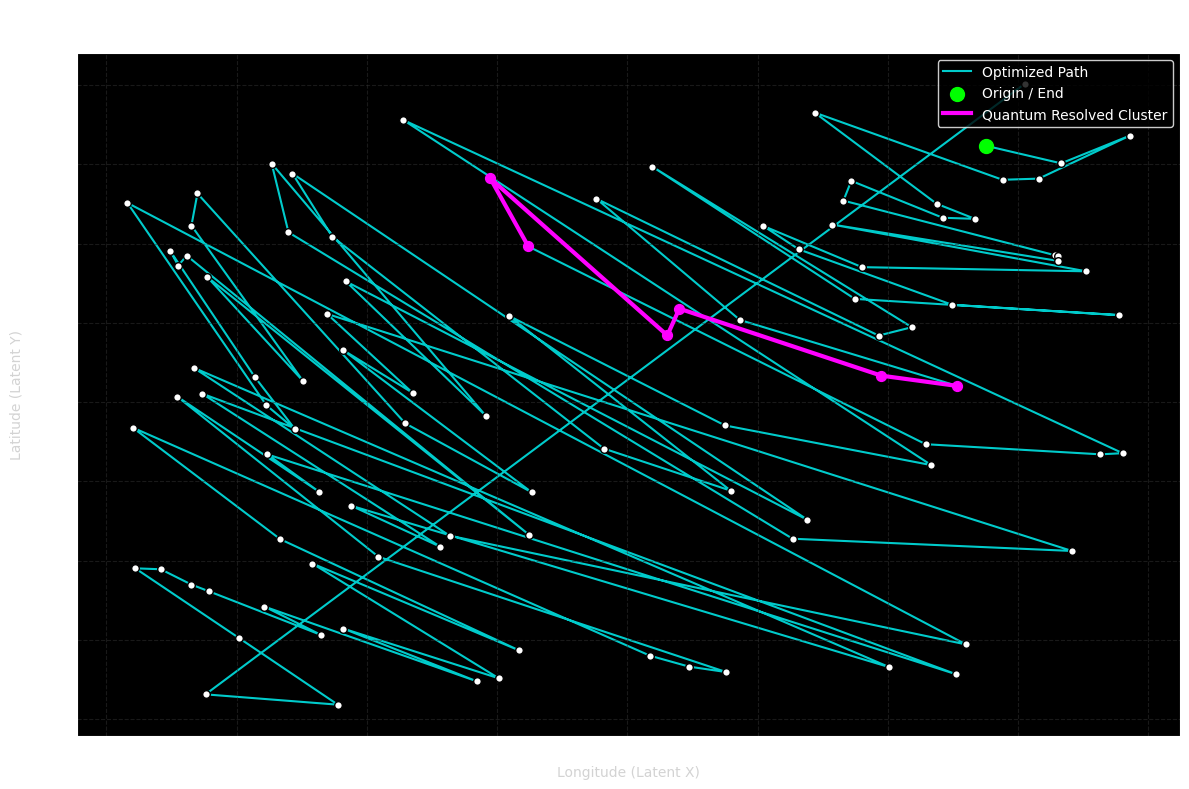

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualize_tekla_route(csv_path='/content/tekla_absolute_route.csv'):
    print(f"🗺️ Loading Manifold Coordinates from {csv_path}...")

    # Load the phase-locked coordinates
    df = pd.read_csv(csv_path)
    x_coords = df['X_Final'].values
    y_coords = df['Y_Final'].values

    # Setup the plot
    plt.figure(figsize=(12, 8))
    plt.style.use('dark_background') # Fits the terminal/quantum aesthetic

    # Plot the route lines
    plt.plot(x_coords, y_coords, color='cyan', linewidth=1.5, alpha=0.8, zorder=1, label="Optimized Path")

    # Plot the city nodes
    plt.scatter(x_coords, y_coords, color='white', s=30, zorder=2, edgecolors='black')

    # Highlight the Origin/Start City (Index 0)
    plt.scatter(x_coords[0], y_coords[0], color='lime', s=100, zorder=3, label="Origin / End")

    # Highlight the Quantum Resolved Cluster (Indices 27 to 32 based on your logs)
    plt.plot(x_coords[27:33], y_coords[27:33], color='magenta', linewidth=3, zorder=4, label="Quantum Resolved Cluster")
    plt.scatter(x_coords[27:33], y_coords[27:33], color='magenta', s=50, zorder=5)

    # Formatting
    plt.title('TekLa Engine: Final Hybrid Neural-Quantum Route', fontsize=16, color='white', pad=20)
    plt.xlabel('Longitude (Latent X)', color='lightgray')
    plt.ylabel('Latitude (Latent Y)', color='lightgray')
    plt.grid(True, color='#333333', linestyle='--', alpha=0.5)
    plt.legend(loc="upper right", facecolor='black', edgecolor='white')

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_tekla_route()

In [ ]:
!zip -r colab_contents.zip /content -x "/content/drive/*"

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.06.04/ (stored 0%)
  adding: content/.config/logs/2026.06.04/13.39.24.274402.log (deflated 58%)
  adding: content/.config/logs/2026.06.04/13.39.12.467650.log (deflated 58%)
  adding: content/.config/logs/2026.06.04/13.39.36.079406.log (deflated 57%)
  adding: content/.config/logs/2026.06.04/13.39.22.644527.log (deflated 87%)
  adding: content/.config/logs/2026.06.04/13.38.54.010366.log (deflated 92%)
  adding: content/.config/logs/2026.06.04/13.39.37.138439.log (deflated 56%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/default_configs.db 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
